# LabPractice 4.1: Forecasting I

For this practice, you will need the following datasets:
- **Unemployment.dat**: dataset containing unemployment data from Spain from 2009 to 2020.
    - DATE: date of the sample
    - TOTAL: total number of unemployed people.

The main package for time series analysis in Python is **statsmodels**.

Further reading:
- [statsmodels](https://www.statsmodels.org/stable/index.html)

In addition, we will be using the following libraries:
- Data management
    - [numpy](https://numpy.org/)
    - [pandas](https://pandas.pydata.org/)

- Plotting
    - [seaborn](https://seaborn.pydata.org/)
    - [matplotlib](https://matplotlib.org/)


In [2]:
# For more information, check https://www.machinelearningplus.com/time-series/time-series-analysis-python/ 
### Load libraries ###
# interactive plotting
#%matplotlib inline
#%config InlineBackend.figure_format = 'svg' # ‘png’, ‘retina’, ‘jpeg’, ‘svg’, ‘pdf’

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
sns.set()

#Define figure sizes
#plt.rcParams.update({'figure.figsize': (8, 5), 'figure.dpi': 120})

# Data management libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from dateutil.parser import parse 

# Machine Learning libraries
from statsmodels.tsa.seasonal import seasonal_decompose, STL
# Others
import math

---
## 1. Read the dataset

In [5]:
# Import data
df = pd.read_csv('Unemployment.dat', parse_dates=['DATE'], dayfirst=True, sep=' ', index_col='DATE')
df.head()

,TOTAL
DATE,
2009-01-01,3327801
2009-02-01,3481859
2009-03-01,3605402
2009-04-01,3644880
2009-05-01,3620139


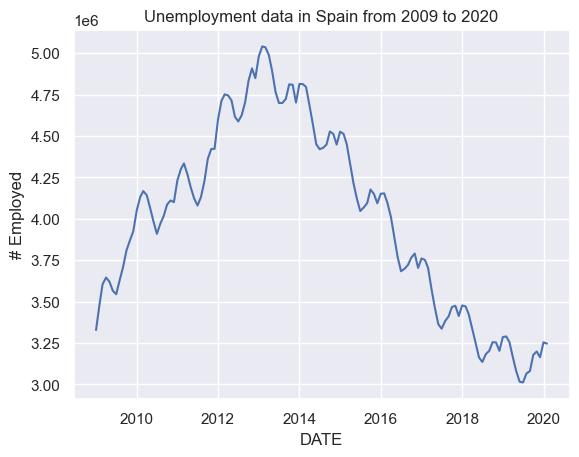

In [7]:
# Plotting a time series
fig, ax = plt.subplots()
ax.plot('TOTAL', data=df)
ax.set(title='Unemployment data in Spain from 2009 to 2020', xlabel='DATE', ylabel='# Employed')
plt.show()
#Tendencia no lineal 
#Parece que basta con una tendencua aditiva, ya que la parte periódica parece no cambiar (diferencia entre máximos y mínimos)

In [16]:
# Extracting a portion of a time series
df_cut = df.loc['2015-03-01':]
df_cut = df.loc[:'2012-08-01']
df_cut = df.loc['2016-01-01':'2017-01-01']
df_cut

,TOTAL
DATE,
2016-01-01,4150755
2016-02-01,4152986
2016-03-01,4094770
2016-04-01,4011171
2016-05-01,3891403
2016-06-01,3767054
2016-07-01,3683061
2016-08-01,3697496
2016-09-01,3720297


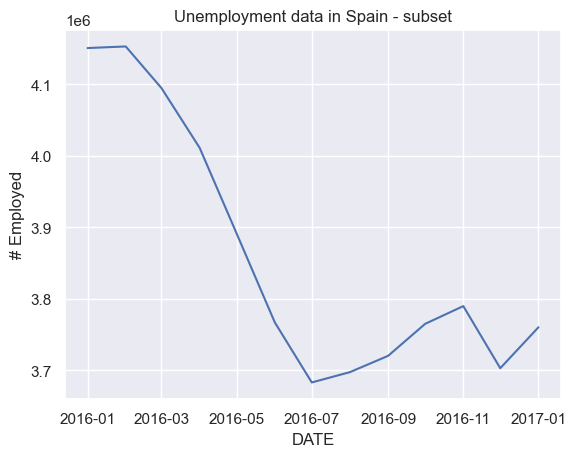

In [18]:
# Plotting subset time series
fig, ax = plt.subplots()
ax.plot('TOTAL', data=df_cut)
ax.set(title='Unemployment data in Spain - subset', xlabel='DATE', ylabel='# Employed')
plt.show()

---
# Decomposition methods

<Figure size 640x480 with 0 Axes>

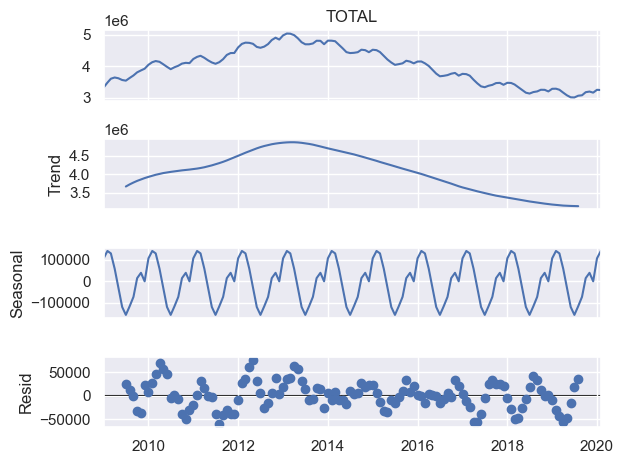

In [20]:
# Additive Decomposition
# Función de seasonal_decompose, model='additive' hace la descomposición aditiva
result_add = seasonal_decompose(df['TOTAL'], model='additive')
plt.figure()
result_add.plot()
plt.show()
#La tendencia tiene que ser algo suave, si se mete algo repetitivo, ya deja de ser tendencia
#La serie del residuo, idealmente, debería ser lo más aleatoria posible. En este caso, hay cierto patrón, lo que nos revela que no es el mejor 
#modelo posible. Eso debería estar dentro de la componente estacionaria

<Figure size 640x480 with 0 Axes>

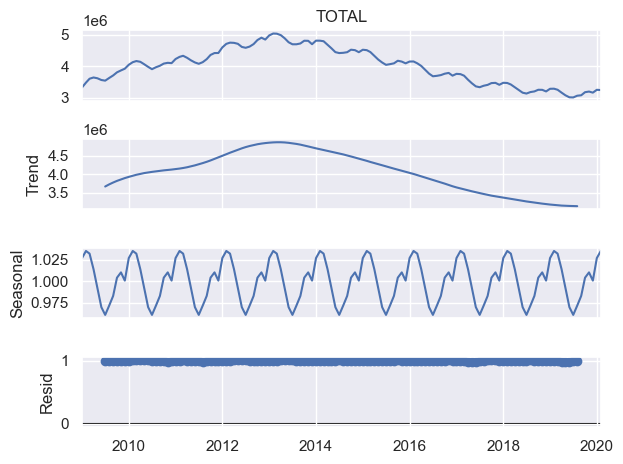

In [28]:
# Multiplicative Decomposition 
result_mul = seasonal_decompose(df['TOTAL'], model='multiplicative')
plt.figure()
result_mul.plot()
plt.show()
#Es importante fijarse en los ejes. 
#En los residuos de la multiplicativa, lo ideal sería aleatorio cercano a 1.


<Figure size 640x480 with 0 Axes>

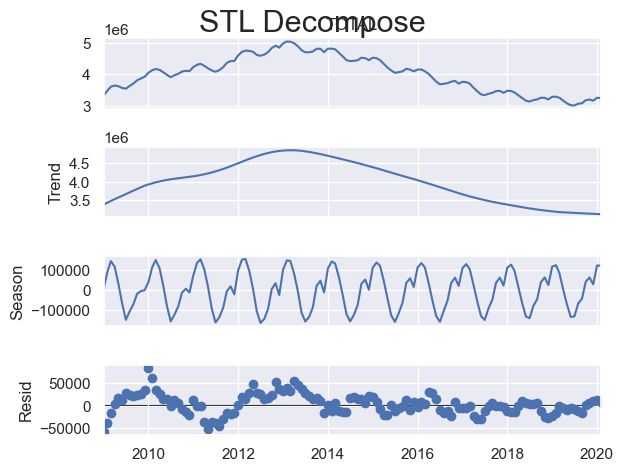

In [24]:
# STL ( Seasonal-Trend decomposition using Loess) Decomposition
stl = STL(df['TOTAL'], period=12)
result_stl = stl.fit()
plt.figure()
result_stl.plot().suptitle('STL Decompose', fontsize=22)
plt.show()
#Permitimos que la componente estacional vaya cambiando. Permite ver cambios en la parte estacionaria. En los primeros años, la diferencia 
#entre máximo y mínimo de la componente estacional, es mayor y desciende conforme pasan los años, lo que nos indica que el empleo temporal 
#ha disminuido

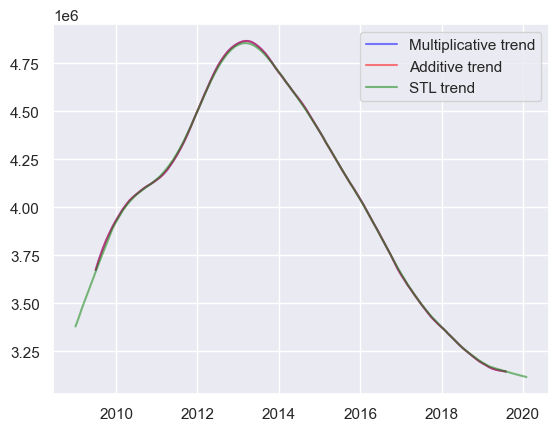

In [30]:
# Plot components together
plt.figure()
plt.plot(result_mul.trend, color='blue', alpha=0.5, label='Multiplicative trend')
plt.plot(result_add.trend, color='red', alpha=0.5, label='Additive trend')
plt.plot(result_stl.trend, color='green', alpha=0.5, label='STL trend')
plt.legend()
plt.show()

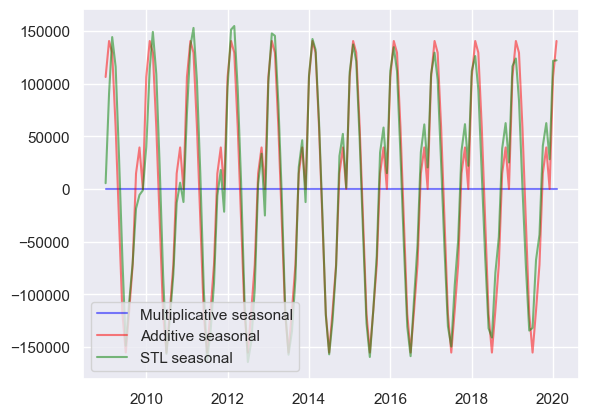

In [32]:
plt.figure()
plt.plot(result_mul.seasonal, color='blue', alpha=0.5, label='Multiplicative seasonal')
plt.plot(result_add.seasonal, color='red', alpha=0.5, label='Additive seasonal')
plt.plot(result_stl.seasonal, color='green', alpha=0.5, label='STL seasonal')
plt.legend()
plt.show()

- Sin estacionalidad, puedes observar con claridad la tendencia subyacente y los patrones a largo plazo.
- Esto te ayuda a identificar:
- Si la serie tiene un crecimiento sostenido o decrecimiento.
- Si existen cambios estructurales importantes en los datos.

Por ejemplo, en una serie de ventas mensuales, quitar la estacionalidad permite analizar si las ventas están aumentando realmente con el tiempo, más allá del pico estacional de Navidad

In [2]:

#Gráfica de tendencia + residuo (le quitamos los efectos de subidas o bajadas estacionales). (Comparar con lo que pasa por ejemplo en el mes de 
#febrero (¿ha subido más de lo que debería subir?)
#Seasonal Adjusted series
plt.figure()
plt.plot(df['TOTAL']/result_mul.seasonal, color='blue', alpha=0.5, label='Multiplicative seasonal')
plt.plot(df['TOTAL']-result_add.seasonal, color='red', alpha=0.5, label='Additive seasonal')
plt.plot(df['TOTAL']-result_stl.seasonal, color='green', alpha=0.5, label='STL seasonal')
plt.legend()
plt.show()

NameError: name 'plt' is not defined